# 02 — Feature Selection
**Goal:** Find which columns actually matter for predicting refills.

Input : `data/clean_data.csv`  
Output: `data/selected_features.csv`, `data/correlation_plot.png`, `data/feature_importance_plot.png`, `data/heatmap.png`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/clean_data.csv', parse_dates=['Date'])
print(f'Loaded {len(df)} rows, {df.shape[1]} columns ')

Loaded 806 rows, 26 columns 


In [2]:
# ── Define candidate features ──────────────────────────────────
# Remove columns that leak the answer or are just identifiers
DROP_COLS = [
    'Date',            # identifier
    'Day',             # string — use Day_Num instead
    'Refill_Required', # original target string
    'Target',          # this IS our target
    'Closing_Stock',   # LEAKS the answer — closing < 2000 means refill!
    'Stock_Ratio',     # same as Closing_Stock, leaks answer
    'Dip',             # derived from Closing_Stock — leaks
]

candidate_features = [c for c in df.columns if c not in DROP_COLS]
print(f'Candidate features ({len(candidate_features)}):')
for f in candidate_features:
    print(f'  {f}')

Candidate features (19):
  Opening_Stock
  MS_Sold
  HSD1_Sold
  HSD2_Sold
  HSD3_Sold
  Total_Sold
  Cash
  Online
  Card
  Year
  Month
  DayOfWeek
  Quarter
  Is_Weekend
  Day_Num
  Rolling_7d_Sales
  Prev_Closing
  Is_Festival_Month
  Is_Monsoon_Month


Correlation of each feature with Refill_Required:
Opening_Stock       -0.8155
Cash                 0.2209
Total_Sold           0.2058
HSD1_Sold            0.2001
Online               0.1895
HSD2_Sold            0.1817
MS_Sold              0.1754
Prev_Closing         0.1687
DayOfWeek            0.1537
Day_Num              0.1537
Card                 0.1505
HSD3_Sold            0.1477
Is_Weekend           0.1051
Rolling_7d_Sales     0.0729
Is_Festival_Month    0.0653
Is_Monsoon_Month    -0.0377
Quarter              0.0172
Month                0.0133
Year                -0.0024


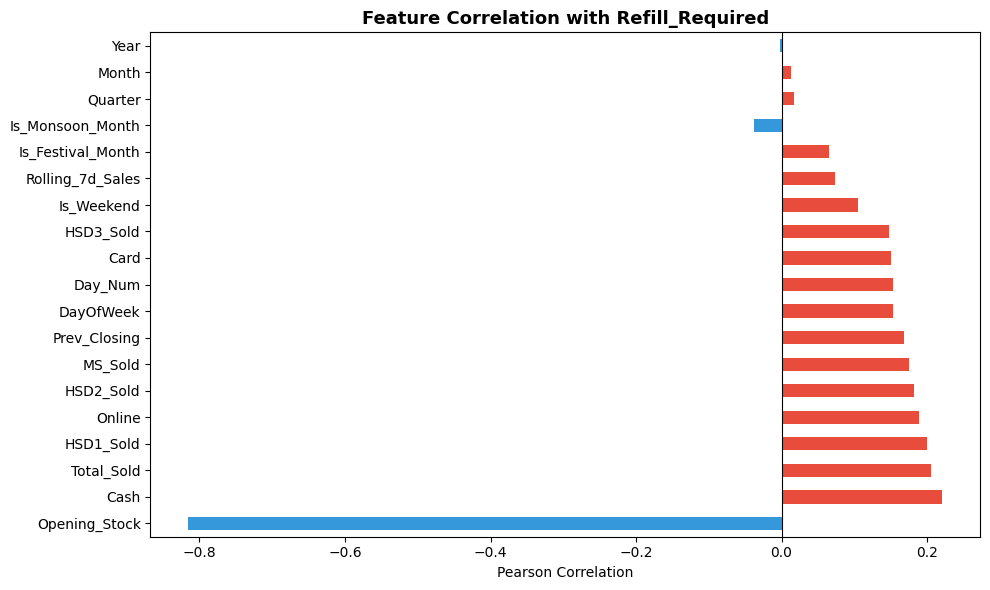

Plot saved 


In [3]:
# ── Correlation with Target ────────────────────────────────────
corr = df[candidate_features + ['Target']].corr()['Target'].drop('Target')
corr = corr.sort_values(key=abs, ascending=False)

print('Correlation of each feature with Refill_Required:')
print(corr.round(4).to_string())

plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in corr]
corr.plot(kind='barh', color=colors)
plt.title('Feature Correlation with Refill_Required', fontsize=13, fontweight='bold')
plt.xlabel('Pearson Correlation')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('../data/correlation_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved ')

Feature Importances:
  Opening_Stock             0.5105
  Prev_Closing              0.2846
  Total_Sold                0.0270
  Cash                      0.0247
  HSD1_Sold                 0.0230
  HSD2_Sold                 0.0211
  Online                    0.0189
  HSD3_Sold                 0.0174
  MS_Sold                   0.0164
  Card                      0.0131
  DayOfWeek                 0.0118
  Rolling_7d_Sales          0.0104
  Day_Num                   0.0088
  Month                     0.0044
  Quarter                   0.0022
  Is_Festival_Month         0.0018
  Is_Weekend                0.0015
  Is_Monsoon_Month          0.0013
  Year                      0.0011


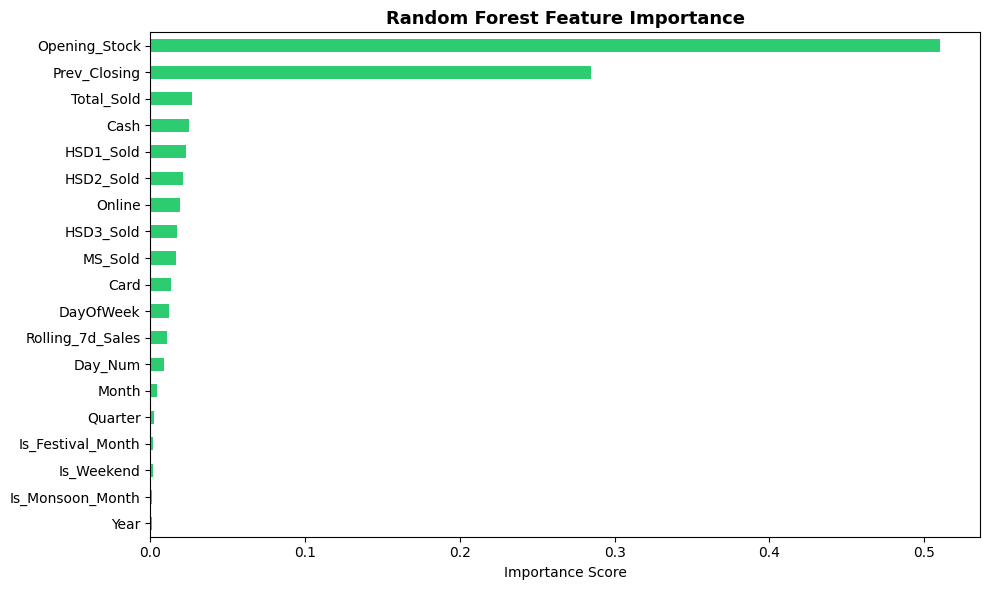

Plot saved 


In [4]:
# ── Random Forest Feature Importance ──────────────────────────
X = df[candidate_features].fillna(0)
y = df['Target']

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=candidate_features)
importances = importances.sort_values(ascending=False)

print('Feature Importances:')
for feat, imp in importances.items():
    print(f'  {feat:<25} {imp:.4f}')

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='#2ecc71')
plt.title('Random Forest Feature Importance', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../data/feature_importance_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved ')

In [5]:
# ── Select Features with importance > 1% ──────────────────────
THRESHOLD = 0.01
selected = importances[importances >= THRESHOLD].index.tolist()

print(f'Selected features (importance ≥ {THRESHOLD*100:.0f}%):')
for f in selected:
    print(f'   {f}  ({importances[f]:.4f})')

dropped = [f for f in candidate_features if f not in selected]
print(f'\nDropped (too low importance):')
for f in dropped:
    print(f'   {f}  ({importances[f]:.4f})')

Selected features (importance ≥ 1%):
   Opening_Stock  (0.5105)
   Prev_Closing  (0.2846)
   Total_Sold  (0.0270)
   Cash  (0.0247)
   HSD1_Sold  (0.0230)
   HSD2_Sold  (0.0211)
   Online  (0.0189)
   HSD3_Sold  (0.0174)
   MS_Sold  (0.0164)
   Card  (0.0131)
   DayOfWeek  (0.0118)
   Rolling_7d_Sales  (0.0104)

Dropped (too low importance):
   Year  (0.0011)
   Month  (0.0044)
   Quarter  (0.0022)
   Is_Weekend  (0.0015)
   Day_Num  (0.0088)
   Is_Festival_Month  (0.0018)
   Is_Monsoon_Month  (0.0013)


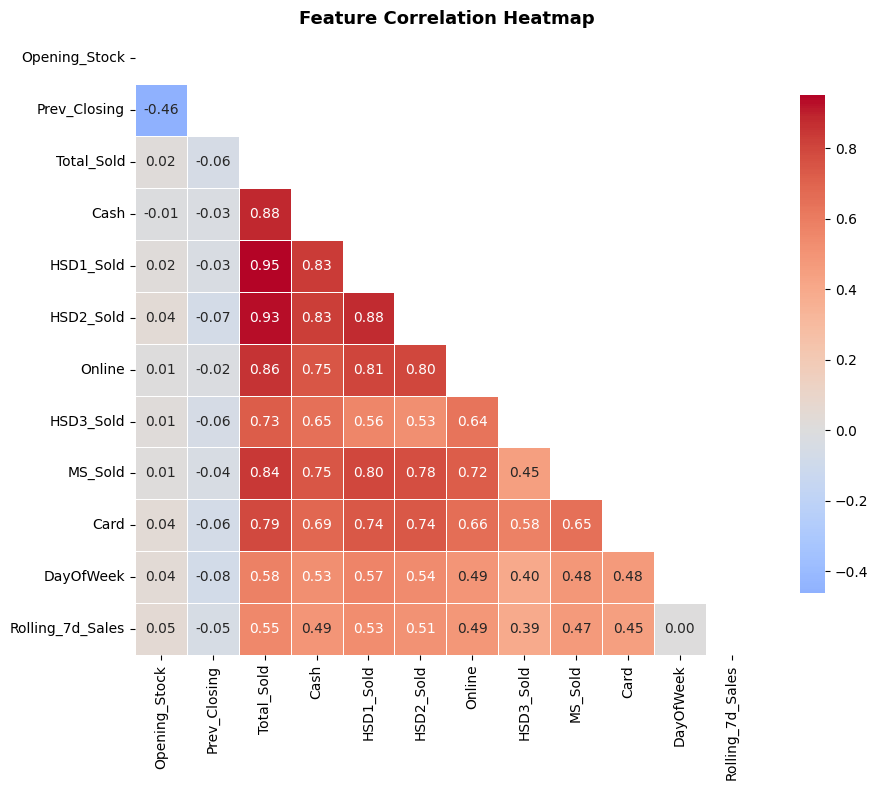

Plot saved 


In [6]:
# ── Correlation Heatmap of selected features ───────────────────
corr_matrix = df[selected].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved ')

In [7]:
# ── Save selected features list ────────────────────────────────
feature_info = pd.DataFrame({
    'Feature':    selected,
    'Importance': [importances[f] for f in selected]
}).sort_values('Importance', ascending=False)

feature_info.to_csv('../data/selected_features.csv', index=False)

print('=== FINAL SELECTED FEATURES ===')
print(feature_info.to_string(index=False))
print(f'\nTotal: {len(selected)} features')
print('\n Saved: data/selected_features.csv')

=== FINAL SELECTED FEATURES ===
         Feature  Importance
   Opening_Stock    0.510538
    Prev_Closing    0.284600
      Total_Sold    0.026952
            Cash    0.024728
       HSD1_Sold    0.022997
       HSD2_Sold    0.021127
          Online    0.018852
       HSD3_Sold    0.017408
         MS_Sold    0.016447
            Card    0.013069
       DayOfWeek    0.011750
Rolling_7d_Sales    0.010412

Total: 12 features

 Saved: data/selected_features.csv
